In [1]:
import dLux.utils as dlu
from jax import numpy as np
from jax import random as jr


import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
from abcdLux.lct import lct_prop
from abcdLux.abcd import compose_abcd, abcd_free_space, abcd_lens


npix = 128
window = 32
diam = 3.0
pscale = dlu.arcsec2rad(17e-3)  # pixel scale in arcseconds per pixel
efl = 1.0  # effective focal length in metres

coords = dlu.pixel_coords(npix, diam)
circle = dlu.circle(coords, diam / 2)

n_zernikes = 50
ab_scale = 1.5e-2
random_coeffs = ab_scale * jr.normal(jr.PRNGKey(2), (n_zernikes,))

screen = [
    random_coeffs[i] * dlu.zernike(j=i + 2, coordinates=coords, diameter=diam)
    for i in range(len(random_coeffs))
]
screen = np.sum(np.array(screen), axis=0)

aperture = circle + screen

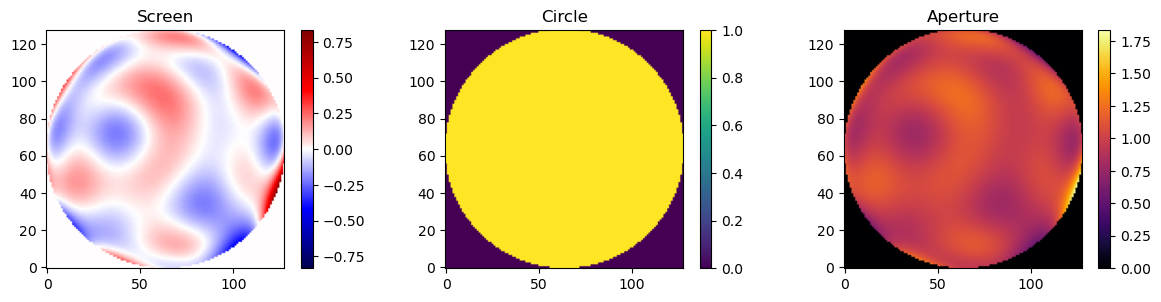

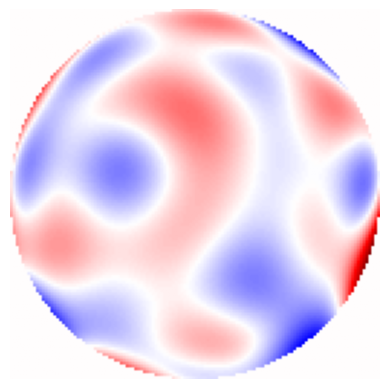

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

im = ax[0].imshow(
    screen, cmap="seismic", norm=mpl.colors.CenteredNorm(), origin="lower"
)
fig.colorbar(im, ax=ax[0])
ax[0].set_title("Screen")

im = ax[1].imshow(circle, cmap="viridis", origin="lower")
fig.colorbar(im, ax=ax[1])
ax[1].set_title("Circle")

im = ax[2].imshow(aperture, cmap="inferno", origin="lower")
fig.colorbar(im, ax=ax[2])
ax[2].set_title("Aperture")
plt.tight_layout()
plt.show()

plt.imshow(screen, cmap="seismic", norm=mpl.colors.CenteredNorm(), origin="lower")
plt.axis("off")
plt.savefig("files/quick_figs/wf.png", bbox_inches="tight", pad_inches=0, dpi=400)
plt.show()

In [4]:
x = np.array(
    [
        5200,
        5220,
        5320,
        5420,
        5520,
        5620,
        5720,
        5820,
        5920,
        6020,
        6120,
        6220,
        6320,
        6420,
        6520,
        6620,
        6720,
        6820,
        6820,
        6920,
        7020,
        7120,
        7220,
        7240,
    ]
)

y = np.array(
    [
        0.0,
        0.00103172,
        0.000971903,
        0.00217544,
        0.0769474,
        0.301793,
        0.453761,
        0.508307,
        0.531563,
        0.548385,
        0.555117,
        0.563032,
        0.575735,
        0.581802,
        0.583188,
        0.577323,
        0.434025,
        0.111108,
        0.111518,
        0.0160013,
        0.00424532,
        0.00160802,
        0.000994543,
        0.0,
    ]
)

In [5]:
defocus = 0  # don't make this larger than 1e-2 to avoid aliasing

wavels = x * 1e-10
psfs = []
for wavel in wavels:
    E_field = lct_prop(
        aperture,  # initial field
        (npix, diam / npix),  # input coord spec
        (window, pscale),  # output coord sec
        wavel,  # wavelength
        compose_abcd(
            [abcd_free_space(efl), abcd_lens(efl), abcd_free_space(efl + defocus)]
        ),  # abcd matrix stuff.  same focal length as hst but that doesn't matter
    )
    psfs.append(np.abs(E_field) ** 2)

psfs = np.array(psfs)
psf = (psfs * y[:, None, None]).sum(0)
psf /= psf.sum()

In [6]:
defocus = 2e-6  # don't make this larger than 1e-2 to avoid aliasing

wavels = x * 1e-10
psfs = []
for wavel in wavels:
    E_field = lct_prop(
        aperture,  # initial field
        (npix, diam / npix),  # input coord spec
        (npix, pscale),  # output coord sec
        wavel,  # wavelength
        compose_abcd(
            [abcd_free_space(efl), abcd_lens(efl), abcd_free_space(efl + defocus)]
        ),  # abcd matrix stuff.  same focal length as hst but that doesn't matter
    )
    psfs.append(np.abs(E_field) ** 2)

psfs = np.array(psfs)
df_psf = (psfs * y[:, None, None]).sum(0)
df_psf /= df_psf.sum()

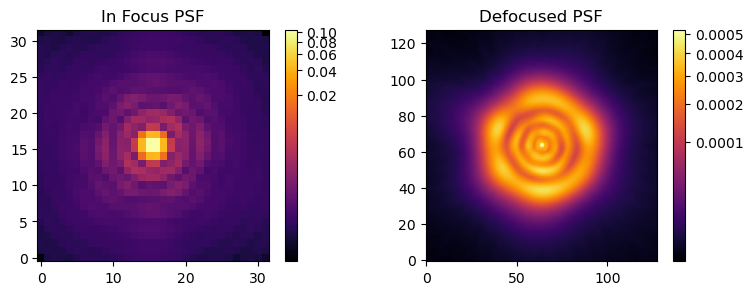

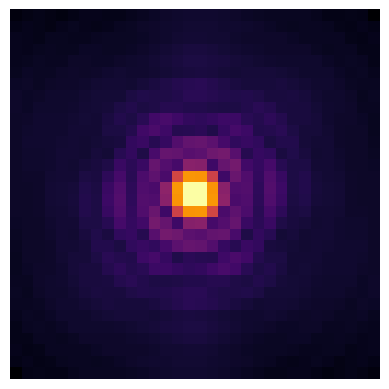

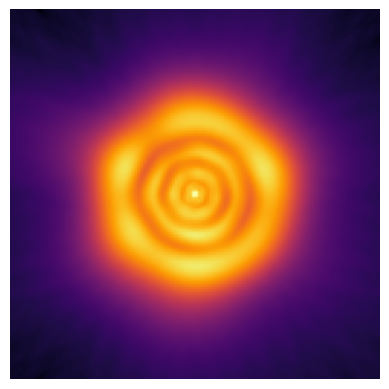

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
im = ax[0].imshow(psf, norm=mpl.colors.PowerNorm(0.2), cmap="inferno", origin="lower")
fig.colorbar(im, ax=ax[0])
ax[0].set_title("In Focus PSF")
im = ax[1].imshow(
    df_psf, norm=mpl.colors.PowerNorm(0.4), cmap="inferno", origin="lower"
)
fig.colorbar(im, ax=ax[1])
ax[1].set_title("Defocused PSF")
plt.tight_layout()
plt.show()

plt.imshow(psf, norm=mpl.colors.PowerNorm(0.3), cmap="inferno", origin="lower")
plt.axis("off")
plt.savefig("files/quick_figs/psf.png", bbox_inches="tight", pad_inches=0, dpi=400)
plt.show()

plt.imshow(df_psf, norm=mpl.colors.PowerNorm(0.3), cmap="inferno", origin="lower")
plt.axis("off")
plt.savefig("files/quick_figs/df_psf.png", bbox_inches="tight", pad_inches=0, dpi=400)
plt.show()

"model"

In [10]:
defocus = 0  # don't make this larger than 1e-2 to avoid aliasing

wavels = x * 1e-10
psfs = []
for wavel in wavels:
    E_field = lct_prop(
        aperture,  # initial field
        (npix, diam / 3 / npix),  # input coord spec
        (3 * window, pscale),  # output coord sec
        wavel,  # wavelength
        compose_abcd(
            [abcd_free_space(efl), abcd_lens(efl), abcd_free_space(efl + defocus)]
        ),  # abcd matrix stuff.  same focal length as hst but that doesn't matter
    )
    psfs.append(np.abs(E_field) ** 2)

psfs = np.array(psfs)
model_psf = (psfs * y[:, None, None]).sum(0)
model_psf /= psf.sum()

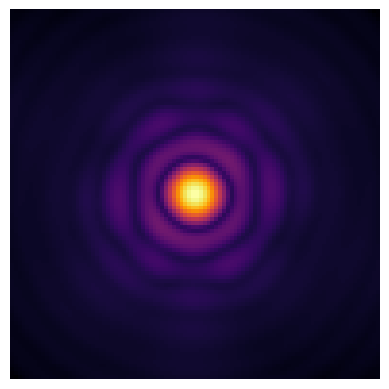

In [11]:
plt.imshow(model_psf, norm=mpl.colors.PowerNorm(0.3), cmap="inferno", origin="lower")
plt.axis("off")
plt.savefig("files/quick_figs/mpsf.png", bbox_inches="tight", pad_inches=0, dpi=400)
plt.show()